# Data Source Comparison

**Energinet DataService** -- Free, no authentication. Authoritative source for DK zones. Hourly resolution, UTC-indexed. Covers prices, wind/solar forecasts, load, production by type, and cross-border flows.

**ENTSO-E Transparency Platform** -- EU-mandated (Regulation 543/2013), covers all European bidding zones. Requires API key. 15-min or hourly resolution depending on data type. Local-time indexed (Europe/Copenhagen for DK).

**Nord Pool** -- Primary marketplace for day-ahead and intraday in the Nordics. Commercial data access.

**Weather** -- DMI (Danish Meteorological Institute) for DK-specific NWP data, ECMWF for pan-European coverage. Wind speed at hub height and solar irradiance are the key inputs for generation forecasts.

For DK zones, we prefer Energinet (longer history in cache, no auth required, native hourly). ENTSO-E fills in the non-DK zones.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from da_forecast.sources.cache import ParquetCache
from da_forecast.config import RAW_DIR

In [2]:
cache = ParquetCache(RAW_DIR)

en_prices = cache.load("energinet", "DK_1", "day_ahead_prices")[["price_eur_mwh"]].copy()
entsoe_prices = cache.load("entsoe", "DK_1", "day_ahead_prices")[["price_eur_mwh"]].copy()

# Normalize both to UTC for comparison
if en_prices.index.tz is not None:
    en_prices.index = en_prices.index.tz_convert("UTC")
else:
    en_prices.index = en_prices.index.tz_localize("UTC")

if entsoe_prices.index.tz is not None:
    entsoe_prices.index = entsoe_prices.index.tz_convert("UTC")
else:
    entsoe_prices.index = entsoe_prices.index.tz_localize("UTC")

print(f"Energinet: {en_prices.index.min()} to {en_prices.index.max()}, {len(en_prices)} rows")
print(f"ENTSO-E:   {entsoe_prices.index.min()} to {entsoe_prices.index.max()}, {len(entsoe_prices)} rows")

Energinet: 2024-10-01 00:00:00+00:00 to 2025-09-30 21:00:00+00:00, 8758 rows
ENTSO-E:   2025-02-28 23:00:00+00:00 to 2025-09-30 22:00:00+00:00, 5136 rows


In [3]:
# Align on overlapping hours
merged = en_prices.join(entsoe_prices, lsuffix="_energinet", rsuffix="_entsoe", how="inner")
merged["diff"] = merged["price_eur_mwh_energinet"] - merged["price_eur_mwh_entsoe"]

print(f"Overlapping hours: {len(merged)}")
print(f"\nDifference stats (Energinet - ENTSO-E):")
print(merged["diff"].describe().round(4))
print(f"\nExact matches (diff == 0): {(merged['diff'].abs() < 0.01).sum()} / {len(merged)}")

Overlapping hours: 5135

Difference stats (Energinet - ENTSO-E):
count    5135.0
mean        0.0
std         0.0
min        -0.0
25%        -0.0
50%         0.0
75%         0.0
max         0.0
Name: diff, dtype: float64

Exact matches (diff == 0): 5135 / 5135


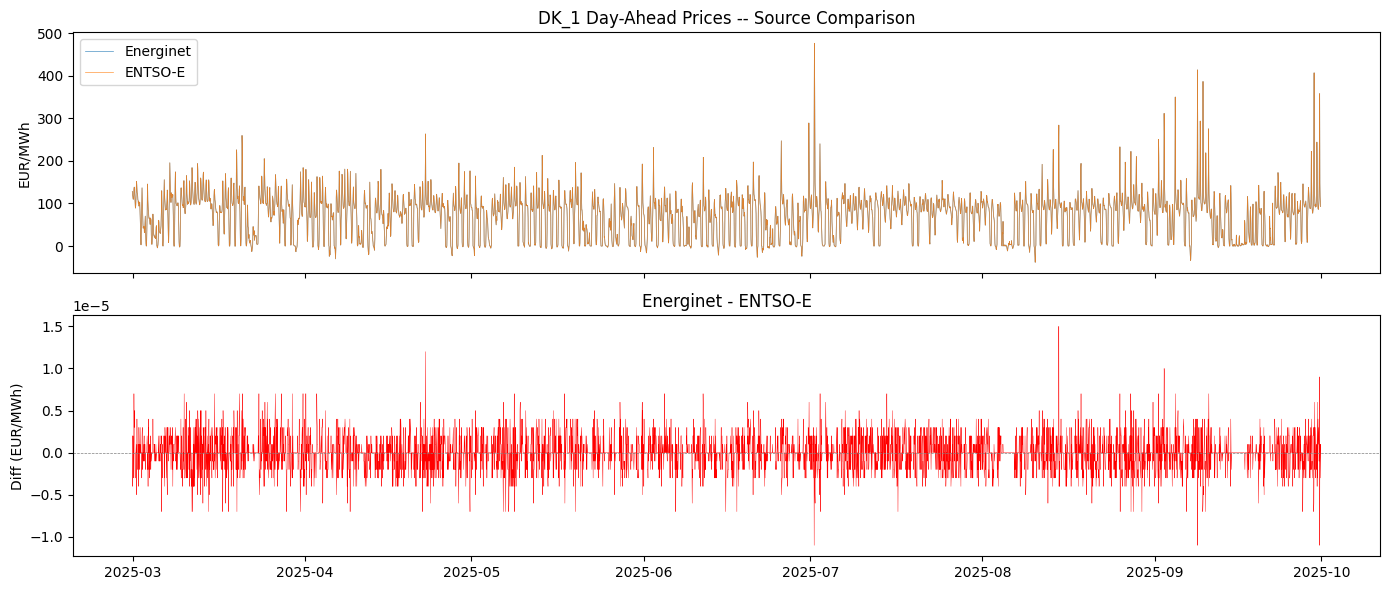

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

ax = axes[0]
ax.plot(merged.index, merged["price_eur_mwh_energinet"], linewidth=0.5, label="Energinet", alpha=0.8)
ax.plot(merged.index, merged["price_eur_mwh_entsoe"], linewidth=0.5, label="ENTSO-E", alpha=0.8)
ax.set_ylabel("EUR/MWh")
ax.legend()
ax.set_title("DK_1 Day-Ahead Prices -- Source Comparison")

ax = axes[1]
ax.plot(merged.index, merged["diff"], linewidth=0.3, color="red")
ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
ax.set_ylabel("Diff (EUR/MWh)")
ax.set_title("Energinet - ENTSO-E")

fig.tight_layout()
plt.show()